# Exploratory Data Analysis for Maynas Dengue Master Dataset

This notebook explores the integrated weekly **master dataset** for Maynas, Loreto, Peru. The purpose is to understand the target, temporal structure, environmental predictors and data-quality characteristics before feature engineering.

**Study period:** 2 January 2000 to 24 December 2023  
**Observation unit:** one observed dengue surveillance week  
**Weekly convention:** Sunday–Saturday, identified by `week_start_date`  
**Master rows:** 1,248 observed dengue weeks


## 1. Setup and data loading

The notebook reads the integrated master table from:

`data/processed/master/maynas_dengue_master_dataset.csv`

All generated EDA tables are written to repository-relative paths under `outputs/eda/`.


In [32]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Resolve repository root from the notebook location:
# notebooks/01_eda_master.ipynb
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "master"
    / "maynas_dengue_master_dataset.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["week_start_date"] = pd.to_datetime(
    df["week_start_date"],
    errors="coerce"
)

date_columns = [
    column
    for column in df.columns
    if column.endswith("_date")
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

df = (
    df
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"First observed week: {df['week_start_date'].min().date()}")
print(f"Last observed week:  {df['week_start_date'].max().date()}")

Rows: 1,248
Columns: 74
First observed week: 2000-01-02
Last observed week:  2023-12-24


## 2. Data integrity and coverage

Before interpreting patterns, confirm that the master table still has the structure established during the earlier audit.

Known characteristics:

- four dengue surveillance weeks are genuinely absent in 2000;
- the first six observed dengue weeks pre-date MODIS NDVI availability;
- temperature/humidity, wind and pressure are complete for all observed dengue weeks;
- precipitation has two incomplete weeks;
- 61 available NDVI records are flagged for relatively low valid-pixel coverage.


In [33]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicate_weeks",
        "rows_with_missing_values",
        "columns_with_missing_values",
        "target_missing_values",
        "target_zero_values",
        "target_negative_values",
    ],
    "value": [
        len(df),
        len(df.columns),
        int(df["week_start_date"].duplicated().sum()),
        int(df.isna().any(axis=1).sum()),
        int((df.isna().sum() > 0).sum()),
        int(df["dengue_cases"].isna().sum()),
        int((df["dengue_cases"] == 0).sum()),
        int((df["dengue_cases"] < 0).sum()),
    ]
})

quality_summary

,metric,value
0,rows,1248
1,columns,74
2,duplicate_weeks,0
3,rows_with_missing_values,6
4,columns_with_missing_values,11
5,target_missing_values,0
6,target_zero_values,0
7,target_negative_values,0


In [34]:
missingness = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missingness["missing_pct"] = (
    missingness["missing_count"]
    / len(df)
    * 100
)

missingness = (
    missingness[
        missingness["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

missingness

,missing_count,missing_pct
ndvi_observation_date,6,0.480769
ndvi_age_days,6,0.480769
ndvi_mean_weekly,6,0.480769
ndvi_median_weekly,6,0.480769
ndvi_std_weekly,6,0.480769
ndvi_min_weekly,6,0.480769
ndvi_max_weekly,6,0.480769
valid_pixel_count,6,0.480769
valid_pixel_fraction_of_max,6,0.480769
low_valid_pixel_coverage,6,0.480769


In [35]:
qa_columns = [
    column
    for column in df.columns
    if (
        "complete" in column.lower()
        or "available" in column.lower()
        or "stale" in column.lower()
        or "coverage" in column.lower()
        or column.startswith("has_")
    )
]

qa_summary = {}

for column in qa_columns:
    qa_summary[column] = (
        df[column]
        .value_counts(
            dropna=False
        )
        .to_dict()
    )

qa_summary

{'precip_week_complete': {True: 1246, False: 2},
 'temp_humidity_week_complete': {True: 1248},
 'wind_week_complete': {True: 1248},
 'pressure_week_complete': {True: 1248},
 'low_valid_pixel_coverage': {False: 1181, True: 61, nan: 6},
 'ndvi_available': {True: 1242, False: 6},
 'ndvi_stale': {False: 1248},
 'has_precipitation_data': {True: 1248},
 'has_temp_humidity_data': {True: 1248},
 'has_wind_data': {True: 1248},
 'has_pressure_data': {True: 1248},
 'has_ndvi_data': {True: 1242, False: 6}}

In [36]:
notes = []

if "precip_week_complete" in df.columns:
    incomplete_precip = int(
        (~df["precip_week_complete"]).sum()
    )

    notes.append(
        f"Incomplete precipitation weeks: {incomplete_precip}"
    )

if "has_ndvi_data" in df.columns:
    missing_ndvi = int(
        (~df["has_ndvi_data"]).sum()
    )

    notes.append(
        f"Weeks without an available NDVI observation: {missing_ndvi}"
    )

if "low_valid_pixel_coverage" in df.columns:
    low_coverage = int(
        (
            df[
                "low_valid_pixel_coverage"
            ]
            == True
        ).sum()
    )

    notes.append(
        f"NDVI rows flagged for low valid-pixel coverage: {low_coverage}"
    )

for note in notes:
    print(note)

Incomplete precipitation weeks: 2
Weeks without an available NDVI observation: 6
NDVI rows flagged for low valid-pixel coverage: 61


### Interpretation - data quality

The master table remains suitable for EDA and downstream modelling. There are **1,248 dengue observations**, no duplicate weeks, and no missing target values. Missingness is confined to the six pre-MODIS rows. The two incomplete precipitation weeks and NDVI quality flags should be retained as QA information rather than treated as reasons to discard observations automatically.


## 3. Dengue epidemiology and temporal behaviour

This section examines the outcome variable itself before considering environmental predictors.


### 3.1 Target distribution


In [37]:
target = df["dengue_cases"]

target_stats = target.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

target_stats

count    1248.000000
mean       55.096154
std       171.856751
min         1.000000
1%          1.000000
5%          3.350000
10%         5.000000
25%         9.000000
50%        20.000000
75%        46.250000
90%       105.000000
95%       179.300000
99%       412.070000
max      2941.000000
Name: dengue_cases, dtype: float64

In [38]:
print(f"Mean:     {target.mean():.2f}")
print(f"Median:   {target.median():.2f}")
print(f"Std dev:  {target.std():.2f}")
print(f"Skewness: {target.skew():.2f}")
print(f"Maximum:  {target.max():.0f}")

Mean:     55.10
Median:   20.00
Std dev:  171.86
Skewness: 11.24
Maximum:  2941


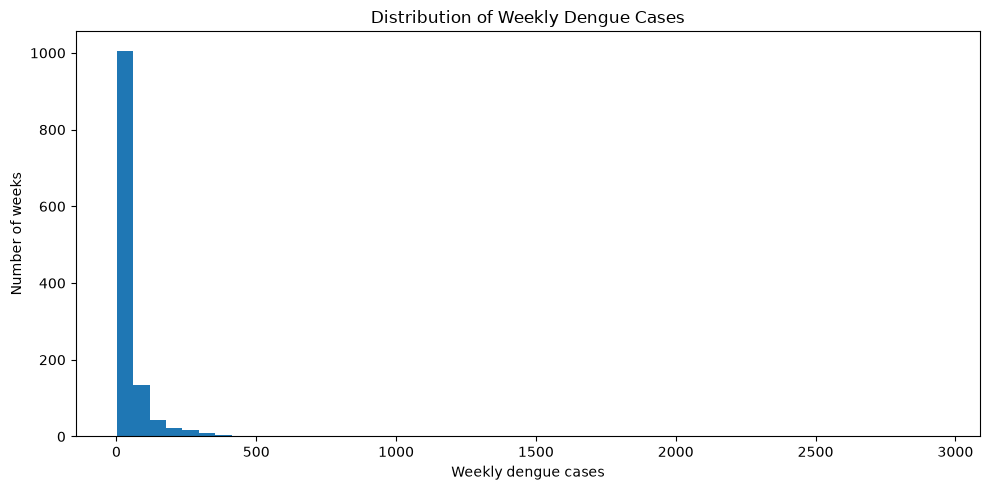

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["dengue_cases"],
    bins=50
)

ax.set_title("Distribution of Weekly Dengue Cases")
ax.set_xlabel("Weekly dengue cases")
ax.set_ylabel("Number of weeks")

plt.tight_layout()
plt.show()

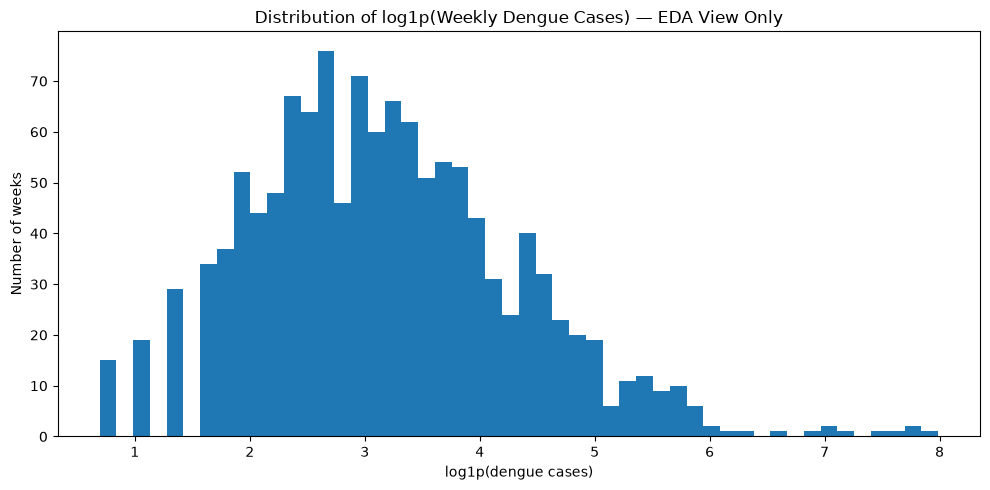

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    np.log1p(df["dengue_cases"]),
    bins=50
)

ax.set_title("Distribution of log1p(Weekly Dengue Cases) — EDA View Only")
ax.set_xlabel("log1p(dengue cases)")
ax.set_ylabel("Number of weeks")

plt.tight_layout()
plt.show()

The log-transformed view is used only to make the shape of the distribution easier to inspect. The modelling target is **not transformed here**.

### Interpretation — target distribution

Weekly dengue incidence is **extremely right-skewed**. The median is 20 cases, compared with a mean of about 55, and the maximum reaches 2,941. This means a relatively small number of epidemic weeks dominate the upper tail.

For later model comparison, **MAE and RMSE should both be reported**. MAE will better represent typical absolute error, whereas RMSE will penalise large misses during epidemic peaks much more heavily. The log-transformed histogram above is descriptive only; the target has not been transformed.


### 3.2 Weekly time series and epidemic peaks


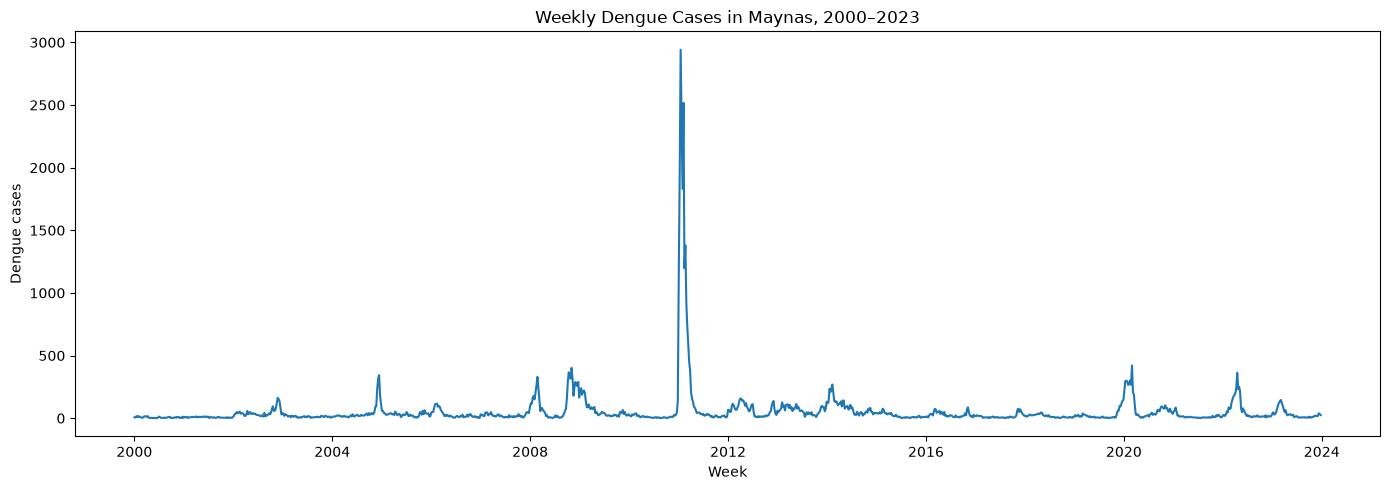

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["week_start_date"],
    df["dengue_cases"]
)

ax.set_title("Weekly Dengue Cases in Maynas, 2000–2023")
ax.set_xlabel("Week")
ax.set_ylabel("Dengue cases")

plt.tight_layout()
plt.show()

In [42]:
top_outbreak_weeks = (
    df[
        [
            "week_start_date",
            "dengue_cases",
            "calendar_year",
            "calendar_month",
            "iso_week",
        ]
    ]
    .sort_values(
        "dengue_cases",
        ascending=False
    )
    .head(20)
)

top_outbreak_weeks

,week_start_date,dengue_cases,calendar_year,calendar_month,iso_week
572,2011-01-16,2941,2011,1,2
575,2011-02-06,2517,2011,2,5
573,2011-01-23,2404,2011,1,3
571,2011-01-09,1944,2011,1,1
574,2011-01-30,1830,2011,1,4
577,2011-02-20,1379,2011,2,7
576,2011-02-13,1197,2011,2,6
570,2011-01-02,1133,2011,1,52
578,2011-02-27,919,2011,2,8
579,2011-03-06,733,2011,3,9


In [43]:
annual_cases = (
    df
    .groupby("calendar_year", as_index=False)
    .agg(
        total_cases=("dengue_cases", "sum"),
        mean_weekly_cases=("dengue_cases", "mean"),
        median_weekly_cases=("dengue_cases", "median"),
        max_weekly_cases=("dengue_cases", "max"),
        observed_weeks=("dengue_cases", "size"),
    )
)

annual_cases.head()

,calendar_year,total_cases,mean_weekly_cases,median_weekly_cases,max_weekly_cases,observed_weeks
0,2000,325,6.632653,5.0,18,49
1,2001,385,7.403846,7.0,14,52
2,2002,2386,45.884615,36.5,163,52
3,2003,667,12.826923,11.5,38,52
4,2004,2347,45.134615,21.5,344,52


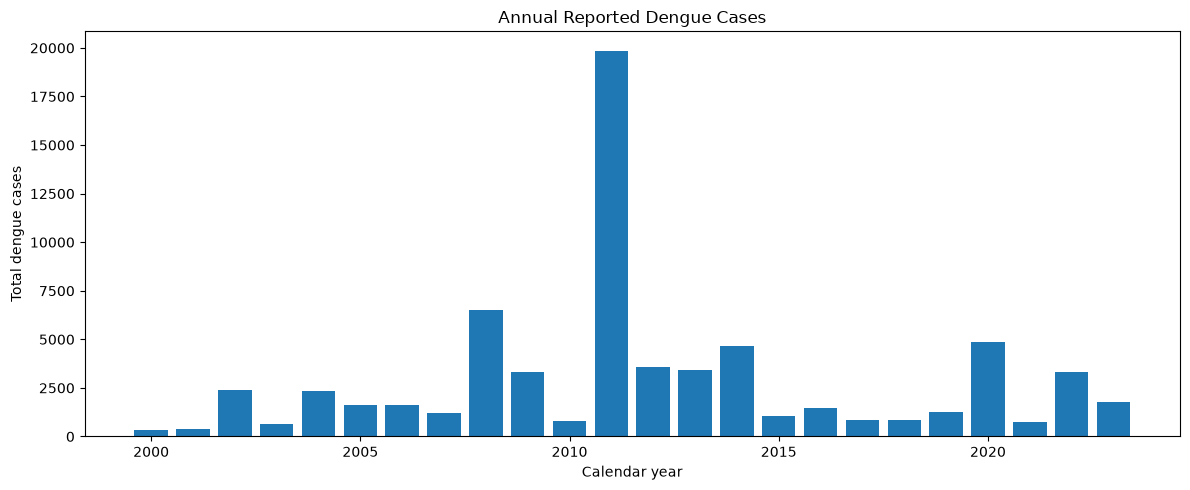

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    annual_cases["calendar_year"],
    annual_cases["total_cases"]
)

ax.set_title("Annual Reported Dengue Cases")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Total dengue cases")

plt.tight_layout()
plt.show()

### Interpretation — outbreaks over time

The most extreme observations cluster in **early 2011**, rather than appearing as isolated random outliers. The highest weekly count is 2,941 on 16 January 2011, and several of the largest observations occur across January and February of the same year. These values represent genuine epidemic behaviour and should not be removed simply because they are statistically extreme.


### 3.3 Seasonal pattern


In [45]:
monthly_dengue = (
    df
    .groupby("calendar_month", as_index=False)
    .agg(
        mean_cases=("dengue_cases", "mean"),
        median_cases=("dengue_cases", "median"),
        max_cases=("dengue_cases", "max"),
        observations=("dengue_cases", "size"),
    )
)

monthly_dengue

,calendar_month,mean_cases,median_cases,max_cases,observations
0,1,152.943925,36.0,2941,107
1,2,132.948454,41.0,2517,97
2,3,80.552381,39.0,733,105
3,4,50.932039,27.0,362,103
4,5,33.952830,20.0,251,106
5,6,25.310000,15.5,109,100
6,7,17.168224,12.0,112,107
7,8,14.352381,10.0,51,105
8,9,18.631068,12.0,156,103
9,10,33.616822,15.0,366,107


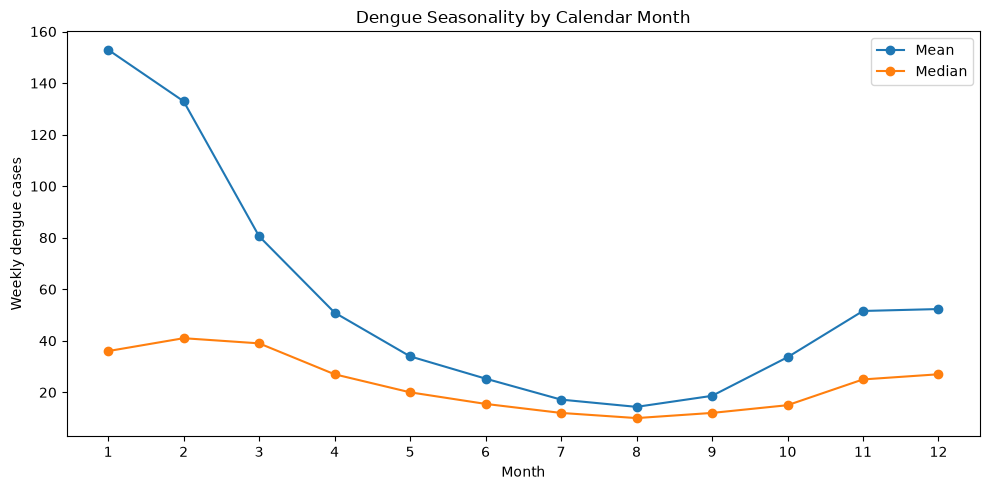

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_dengue["calendar_month"],
    monthly_dengue["mean_cases"],
    marker="o",
    label="Mean"
)

ax.plot(
    monthly_dengue["calendar_month"],
    monthly_dengue["median_cases"],
    marker="o",
    label="Median"
)

ax.set_title("Dengue Seasonality by Calendar Month")
ax.set_xlabel("Month")
ax.set_ylabel("Weekly dengue cases")
ax.set_xticks(range(1, 13))
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation — dengue seasonality

Dengue shows a clear annual pattern. Median incidence is highest around **February and March**, while January and February have especially large means because major epidemic years inflate the averages. The gap between monthly means and medians reinforces the importance of describing both typical seasonal behaviour and exceptional outbreaks.

Seasonality should therefore be represented explicitly during feature engineering, preferably with **cyclical time features** rather than treating calendar month as a simple linear integer.


### 3.4 Dengue autocorrelation and lag structure

Recent dengue incidence may itself be one of the strongest predictors of future incidence. The following analysis uses a **complete Sunday calendar** so that a one-week lag always means exactly one calendar week earlier. The four known missing surveillance weeks remain `NaN` and are excluded pairwise rather than being treated as zero.


In [47]:
# Build a complete Sunday-based weekly dengue series so that a lag of n
# always means exactly n calendar weeks earlier. Known missing surveillance
# weeks remain NaN and are excluded pairwise from each correlation.

dengue_weekly = (
    df[["week_start_date", "dengue_cases"]]
    .drop_duplicates(subset="week_start_date")
    .set_index("week_start_date")
    .sort_index()
    .asfreq("W-SUN")
)

KNOWN_DENGUE_GAPS = pd.DatetimeIndex([
    "2000-04-30",
    "2000-06-11",
    "2000-06-25",
    "2000-07-09",
])

missing_weeks = dengue_weekly.index[
    dengue_weekly["dengue_cases"].isna()
]

unexpected_missing_weeks = missing_weeks.difference(
    KNOWN_DENGUE_GAPS
)

print(f"Complete calendar weeks: {len(dengue_weekly):,}")
print(f"Observed dengue weeks:   {dengue_weekly['dengue_cases'].notna().sum():,}")
print(f"Missing surveillance weeks retained as NaN: {len(missing_weeks):,}")

if len(unexpected_missing_weeks) > 0:
    raise ValueError(
        "Unexpected missing dengue calendar weeks found: "
        + ", ".join(
            date.strftime("%Y-%m-%d")
            for date in unexpected_missing_weeks
        )
    )

if len(missing_weeks) != len(KNOWN_DENGUE_GAPS):
    raise ValueError(
        "The complete dengue calendar does not contain exactly the "
        "four previously documented surveillance gaps."
    )

MAX_DENGUE_LAG = 16

dengue_lag_rows = []

for lag in range(1, MAX_DENGUE_LAG + 1):

    comparison = pd.DataFrame({
        "current_dengue_cases": dengue_weekly["dengue_cases"],
        "lagged_dengue_cases": dengue_weekly["dengue_cases"].shift(lag),
    }).dropna()

    dengue_lag_rows.append({
        "lag_weeks": lag,
        "paired_weeks": len(comparison),
        "pearson_r": comparison["current_dengue_cases"].corr(
            comparison["lagged_dengue_cases"],
            method="pearson"
        ),
        "spearman_rho": comparison["current_dengue_cases"].corr(
            comparison["lagged_dengue_cases"],
            method="spearman"
        ),
    })

dengue_lag_df = pd.DataFrame(dengue_lag_rows)

dengue_lag_df


Complete calendar weeks: 1,252
Observed dengue weeks:   1,248
Missing surveillance weeks retained as NaN: 4


,lag_weeks,paired_weeks,pearson_r,spearman_rho
0,1,1243,0.912835,0.902078
1,2,1244,0.824722,0.851789
2,3,1241,0.701091,0.805059
3,4,1241,0.565817,0.760476
4,5,1239,0.460309,0.716916
5,6,1239,0.348299,0.664413
6,7,1237,0.273610,0.621334
7,8,1237,0.202157,0.578010
8,9,1235,0.149649,0.527766
9,10,1235,0.106983,0.478733


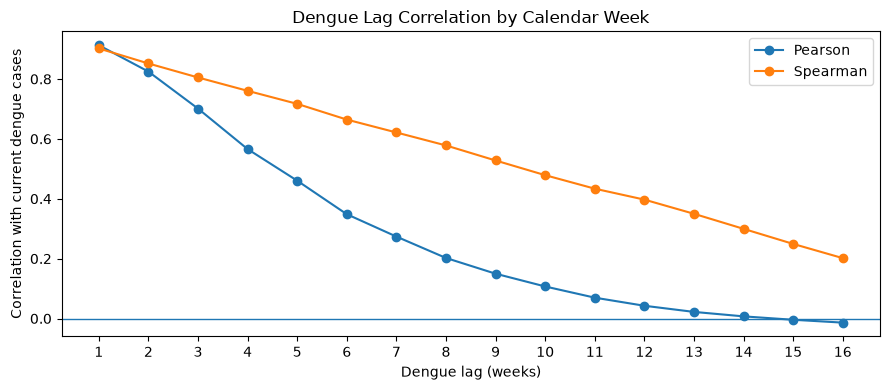

In [48]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    dengue_lag_df["lag_weeks"],
    dengue_lag_df["pearson_r"],
    marker="o",
    label="Pearson"
)

ax.plot(
    dengue_lag_df["lag_weeks"],
    dengue_lag_df["spearman_rho"],
    marker="o",
    label="Spearman"
)

ax.axhline(0, linewidth=1)

ax.set_title("Dengue Lag Correlation by Calendar Week")
ax.set_xlabel("Dengue lag (weeks)")
ax.set_ylabel("Correlation with current dengue cases")
ax.set_xticks(range(1, MAX_DENGUE_LAG + 1))
ax.legend()

plt.tight_layout()
plt.show()


In [49]:
strongest_dengue_lags = (
    dengue_lag_df
    .assign(
        abs_spearman=lambda x: x["spearman_rho"].abs()
    )
    .sort_values(
        "abs_spearman",
        ascending=False
    )
)

print("Strongest dengue lags by absolute Spearman correlation:")
display(strongest_dengue_lags.head(10))

# Also retain the lags in chronological order for easier interpretation.
print("\nFull lag profile:")
display(dengue_lag_df)


Strongest dengue lags by absolute Spearman correlation:


,lag_weeks,paired_weeks,pearson_r,spearman_rho,abs_spearman
0,1,1243,0.912835,0.902078,0.902078
1,2,1244,0.824722,0.851789,0.851789
2,3,1241,0.701091,0.805059,0.805059
3,4,1241,0.565817,0.760476,0.760476
4,5,1239,0.460309,0.716916,0.716916
5,6,1239,0.348299,0.664413,0.664413
6,7,1237,0.273610,0.621334,0.621334
7,8,1237,0.202157,0.578010,0.578010
8,9,1235,0.149649,0.527766,0.527766
9,10,1235,0.106983,0.478733,0.478733



Full lag profile:


,lag_weeks,paired_weeks,pearson_r,spearman_rho
0,1,1243,0.912835,0.902078
1,2,1244,0.824722,0.851789
2,3,1241,0.701091,0.805059
3,4,1241,0.565817,0.760476
4,5,1239,0.460309,0.716916
5,6,1239,0.348299,0.664413
6,7,1237,0.273610,0.621334
7,8,1237,0.202157,0.578010
8,9,1235,0.149649,0.527766
9,10,1235,0.106983,0.478733


### Interpretation — dengue autocorrelation

The dengue series is **strongly autocorrelated**. The one-week lag has a Spearman correlation of approximately **0.90**, with the relationship remaining substantial over several subsequent weeks and then gradually decaying.

This has an important consequence for the modelling design: a climate-only model is not an adequate benchmark. A stronger test of the project hypothesis is to compare:

1. a simple seasonal/persistence benchmark;
2. a model using **past dengue + seasonality**;
3. the same modelling approach using **past dengue + seasonality + climate/environmental features**.

Improvement from the second to the third specification provides clearer evidence of whether environmental variables add predictive information beyond the disease's own temporal persistence.


## 4. Environmental predictor behaviour

The master dataset intentionally retains candidate predictors, alternative summaries and QA fields. This section describes the environmental variables before assessing their relationship with dengue.


### 4.1 Predictor groups and descriptive statistics


In [50]:
predictor_groups = {
    "precipitation": [
        column
        for column in df.columns
        if (
            column.startswith("precip_")
            or column == "rain_days"
        )
        and pd.api.types.is_numeric_dtype(df[column])
    ],

    "temperature_humidity": [
        column
        for column in df.columns
        if any(
            token in column
            for token in [
                "temperature_c_",
                "dewpoint_c_",
                "relative_humidity_pct_",
                "specific_humidity_kgkg_",
            ]
        )
        and pd.api.types.is_numeric_dtype(df[column])
    ],

    "wind": [
        column
        for column in df.columns
        if any(
            token in column
            for token in [
                "u_wind_ms_",
                "v_wind_ms_",
                "wind_speed_ms_",
            ]
        )
        and pd.api.types.is_numeric_dtype(df[column])
    ],

    "pressure": [
        column
        for column in df.columns
        if column.startswith("surface_pressure_hpa_")
        and pd.api.types.is_numeric_dtype(df[column])
    ],

    "ndvi": [
        column
        for column in df.columns
        if column.startswith("ndvi_")
        and pd.api.types.is_numeric_dtype(df[column])
    ],
}

for group, columns in predictor_groups.items():
    print(f"{group}: {len(columns)} variables")
    print(columns)
    print()

precipitation: 11 variables
['precip_sum_mm', 'precip_mean_daily_mm', 'precip_max_daily_mm', 'precip_min_daily_mm', 'rain_days', 'precip_calendar_days_present', 'precip_days_observed', 'precip_mean_valid_grid_cells', 'precip_rain_day_threshold_mm', 'precip_missing_days', 'precip_week_complete']

temperature_humidity: 12 variables
['temperature_c_mean', 'temperature_c_min', 'temperature_c_max', 'dewpoint_c_mean', 'dewpoint_c_min', 'dewpoint_c_max', 'relative_humidity_pct_mean', 'relative_humidity_pct_min', 'relative_humidity_pct_max', 'specific_humidity_kgkg_mean', 'specific_humidity_kgkg_min', 'specific_humidity_kgkg_max']

wind: 9 variables
['u_wind_ms_mean', 'u_wind_ms_min', 'u_wind_ms_max', 'v_wind_ms_mean', 'v_wind_ms_min', 'v_wind_ms_max', 'wind_speed_ms_mean', 'wind_speed_ms_min', 'wind_speed_ms_max']

pressure: 3 variables
['surface_pressure_hpa_mean', 'surface_pressure_hpa_min', 'surface_pressure_hpa_max']

ndvi: 9 variables
['ndvi_age_days', 'ndvi_mean_weekly', 'ndvi_median_we

In [51]:
core_environmental_features = [
    "precip_sum_mm",
    "precip_max_daily_mm",
    "rain_days",
    "temperature_c_mean",
    "temperature_c_min",
    "temperature_c_max",
    "relative_humidity_pct_mean",
    "dewpoint_c_mean",
    "specific_humidity_kgkg_mean",
    "wind_speed_ms_mean",
    "wind_speed_ms_max",
    "surface_pressure_hpa_mean",
    "ndvi_mean_weekly",
    "ndvi_median_weekly",
]

core_environmental_features = [
    column
    for column in core_environmental_features
    if column in df.columns
]

df[core_environmental_features].describe().T

,count,mean,std,min,25%,50%,75%,max
precip_sum_mm,1248.0,61.832686,27.655300,0.329600,42.237700,60.288350,79.502200,157.558500
precip_max_daily_mm,1248.0,21.428865,10.563677,0.257700,13.897550,20.225800,27.310000,82.253200
rain_days,1248.0,6.044872,1.341906,0.000000,5.000000,7.000000,7.000000,7.000000
temperature_c_mean,1248.0,24.220882,1.080110,21.075386,23.505785,24.217863,24.932121,28.554441
temperature_c_min,1248.0,20.925389,1.235154,14.605247,20.253355,21.123477,21.796058,23.709577
temperature_c_max,1248.0,31.982449,2.509096,24.140114,30.143407,31.878199,33.807788,40.302997
relative_humidity_pct_mean,1248.0,89.305417,6.621291,54.384066,86.026786,91.209272,94.373730,98.219506
dewpoint_c_mean,1248.0,21.963870,1.293769,16.542857,21.153674,22.227576,22.951181,24.847061
specific_humidity_kgkg_mean,1248.0,0.016769,0.001301,0.011948,0.015938,0.017006,0.017767,0.019948
wind_speed_ms_mean,1248.0,0.779245,0.143476,0.468446,0.678180,0.762480,0.863170,1.439683


### 4.2 Environmental distributions


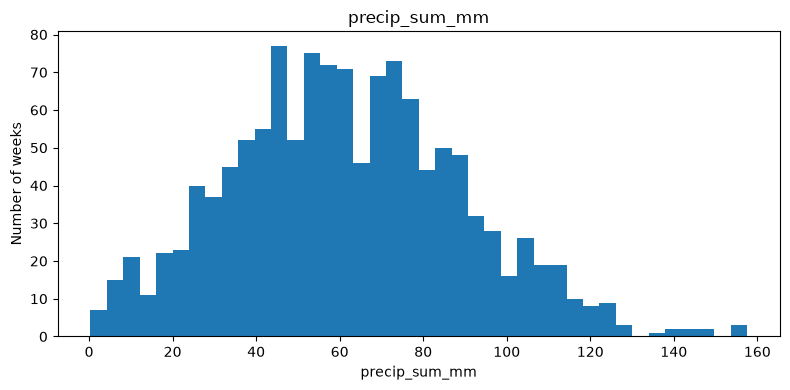

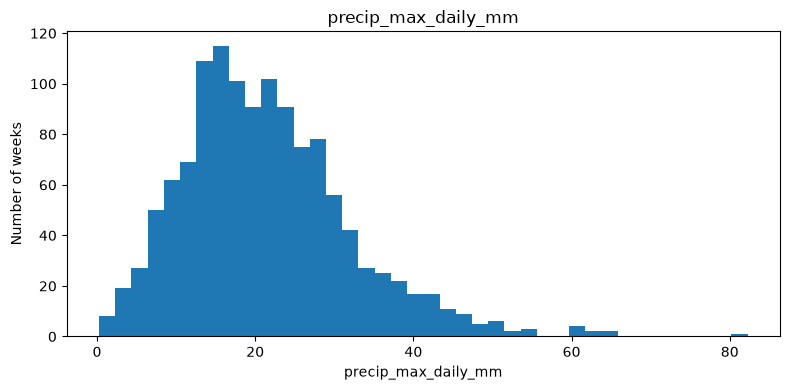

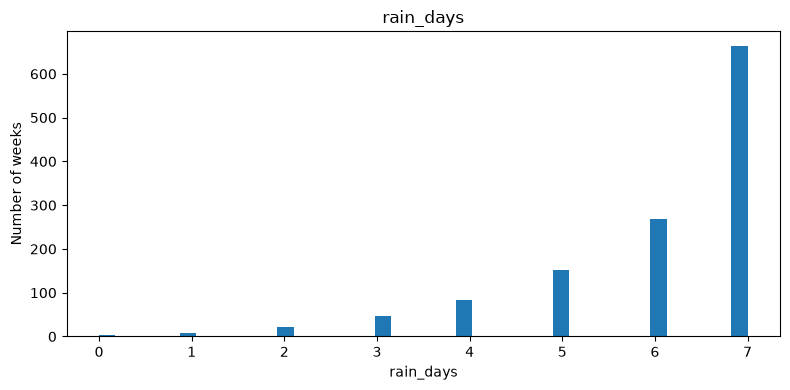

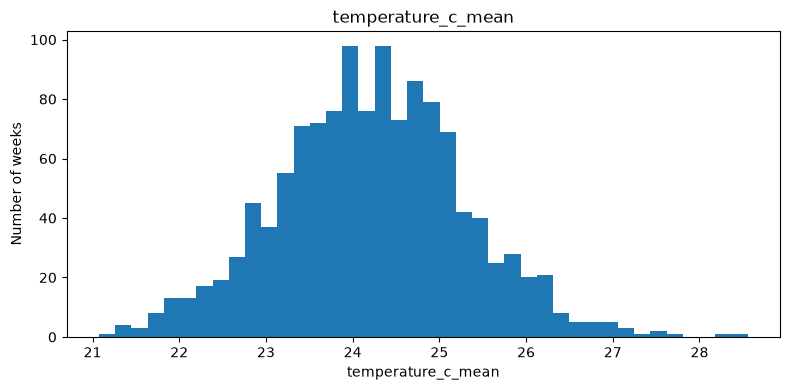

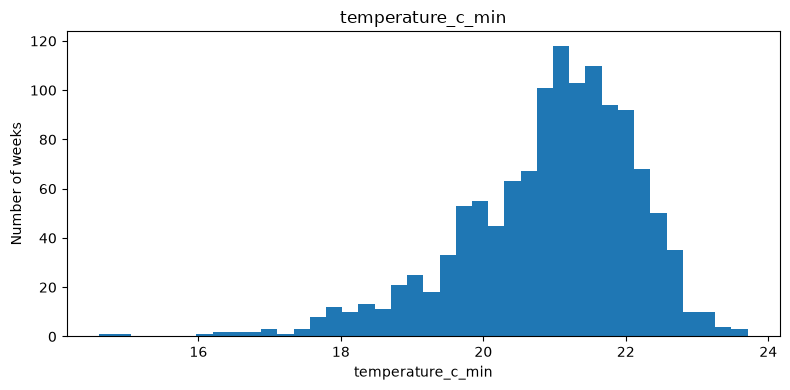

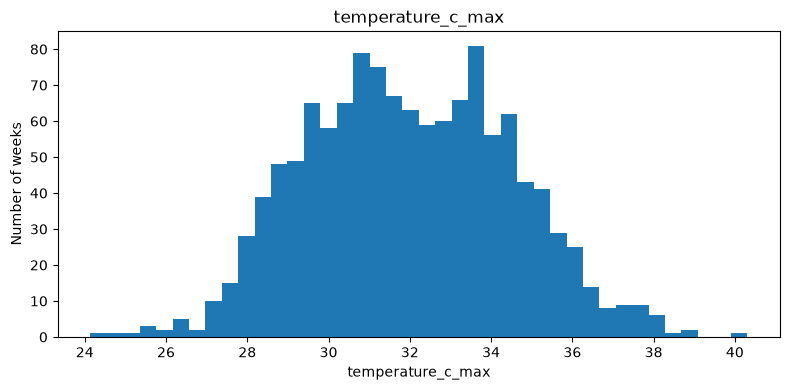

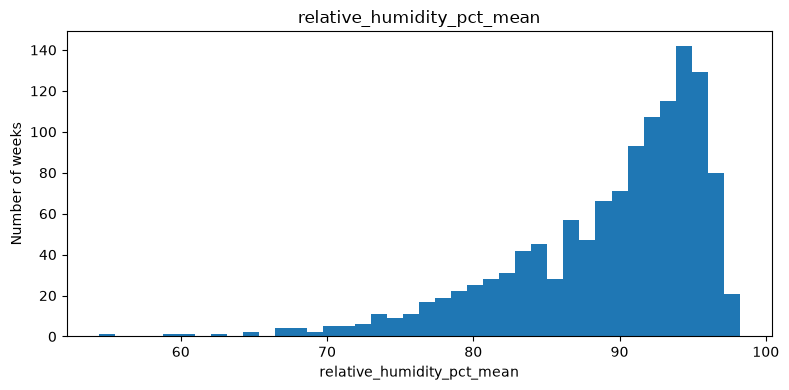

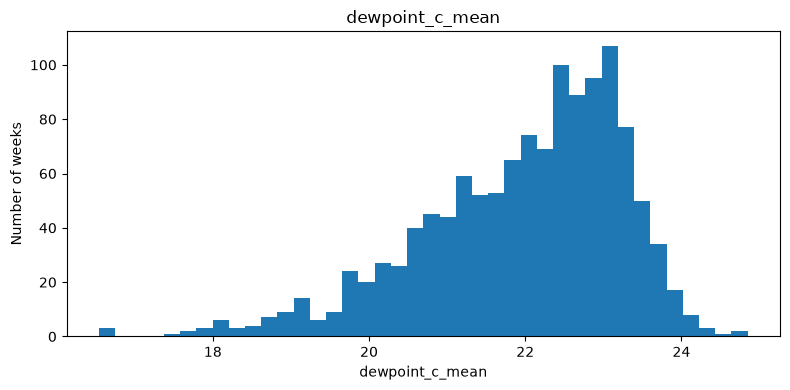

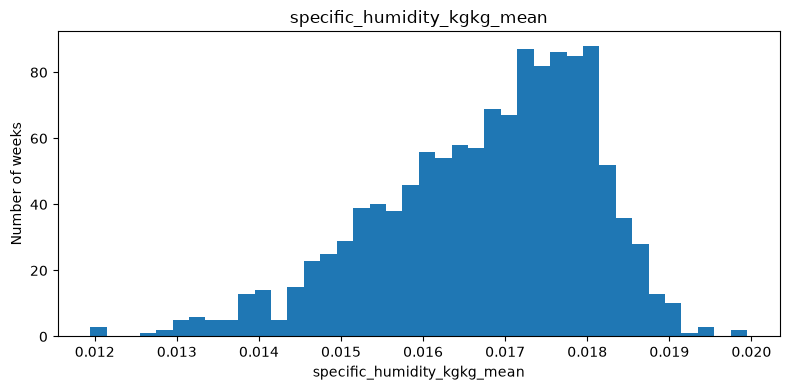

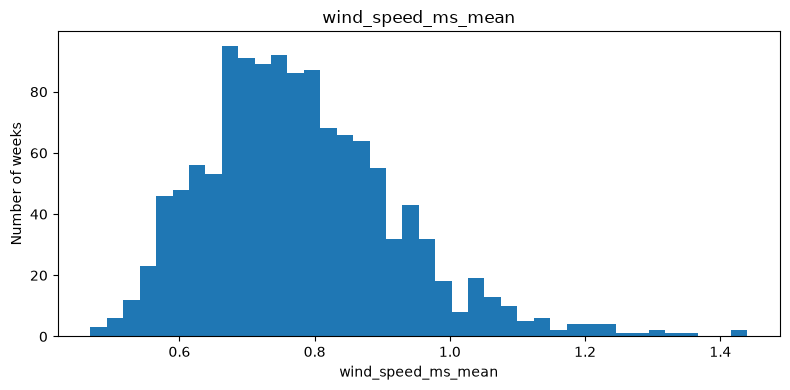

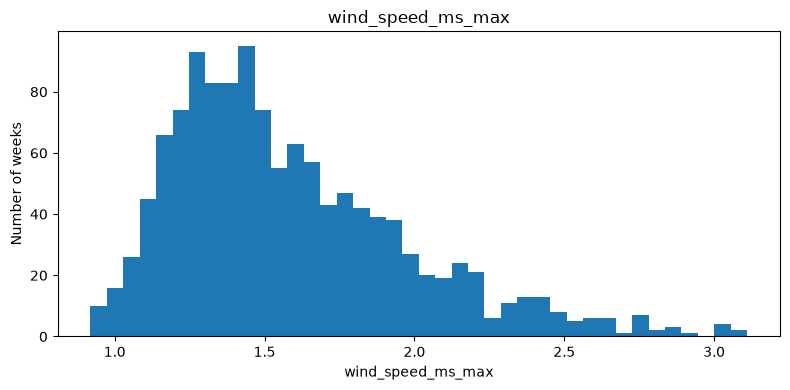

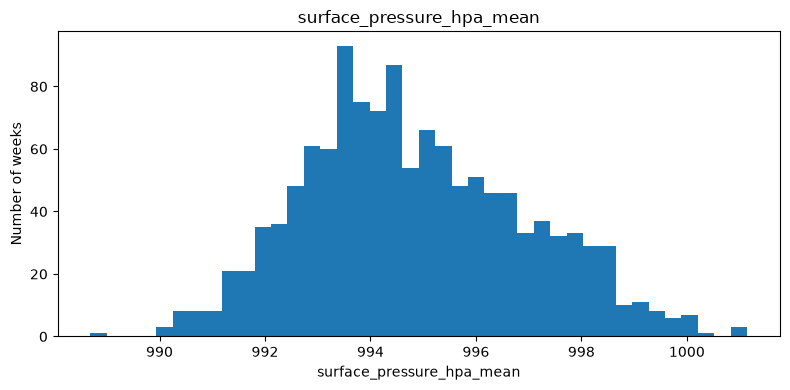

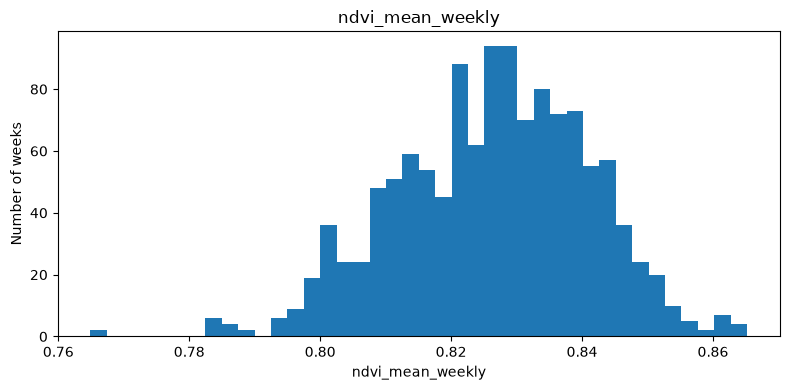

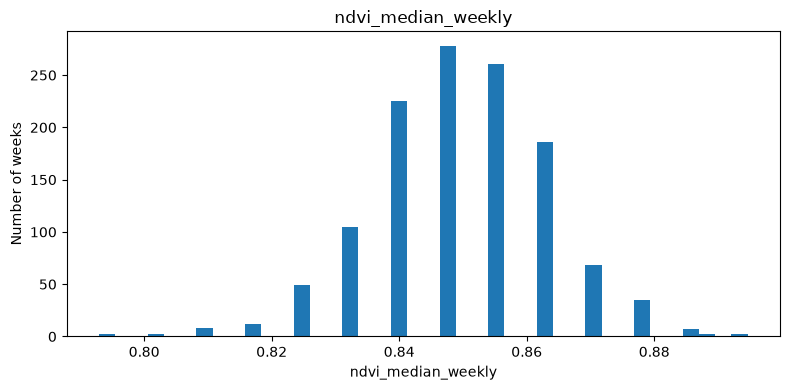

In [52]:
for column in core_environmental_features:
    fig, ax = plt.subplots(figsize=(8, 4))

    values = df[column].dropna()

    ax.hist(
        values,
        bins=40
    )

    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Number of weeks")

    plt.tight_layout()
    plt.show()

### 4.3 Environmental seasonality


In [53]:
seasonal_features = [
    column
    for column in [
        "precip_sum_mm",
        "temperature_c_mean",
        "relative_humidity_pct_mean",
        "wind_speed_ms_mean",
        "surface_pressure_hpa_mean",
        "ndvi_mean_weekly",
    ]
    if column in df.columns
]

monthly_environment = (
    df
    .groupby("calendar_month")[
        seasonal_features
    ]
    .mean()
)

monthly_environment

,precip_sum_mm,temperature_c_mean,relative_humidity_pct_mean,wind_speed_ms_mean,surface_pressure_hpa_mean,ndvi_mean_weekly
calendar_month,,,,,,
1,58.186433,24.468637,88.613500,0.815974,993.575132,0.829736
2,67.242474,24.427656,91.740369,0.754983,993.551857,0.819702
3,82.931422,24.168809,93.782231,0.733376,993.928271,0.816438
4,74.635354,23.932012,94.252682,0.710328,994.749448,0.816507
5,68.790712,23.443716,93.694431,0.690763,996.232716,0.817758
6,58.227938,22.820422,91.039387,0.728356,997.711545,0.820330
7,51.673848,23.141833,87.249695,0.797580,997.749209,0.828176
8,44.458848,24.337734,81.899562,0.820252,996.507034,0.831845
9,51.075297,25.087332,82.210696,0.787425,995.061516,0.832546


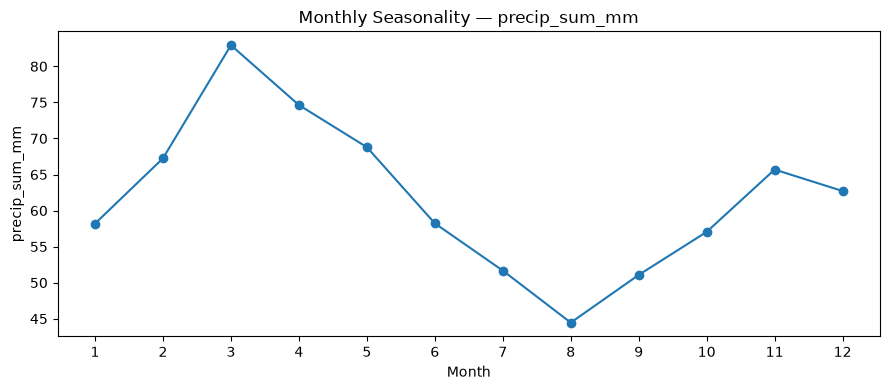

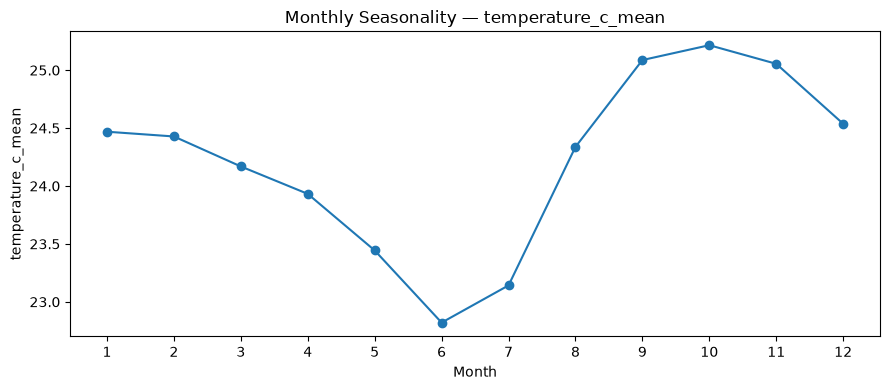

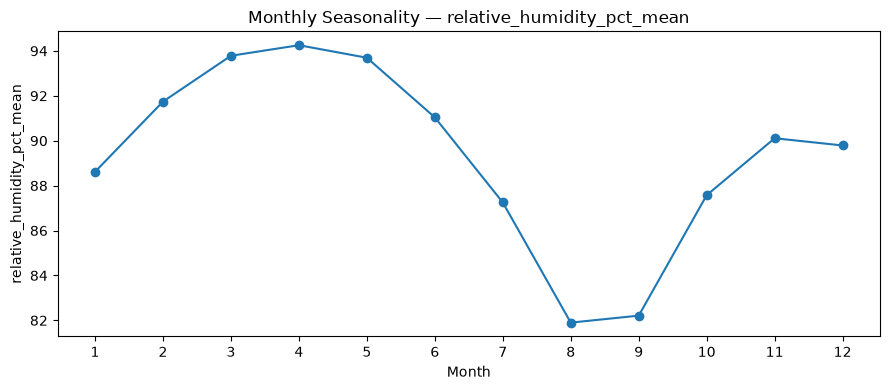

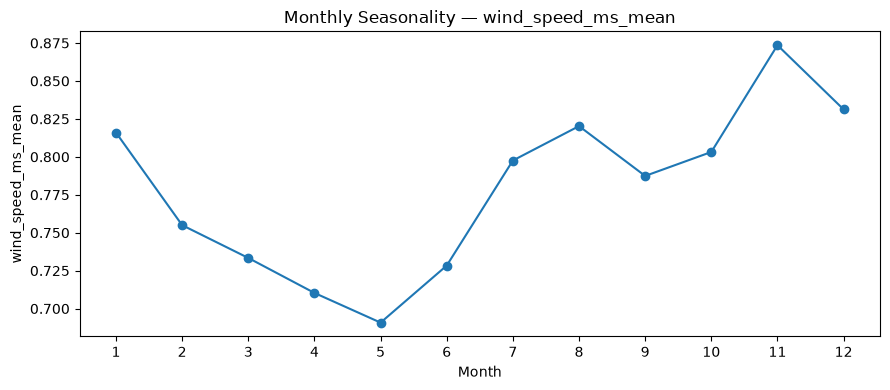

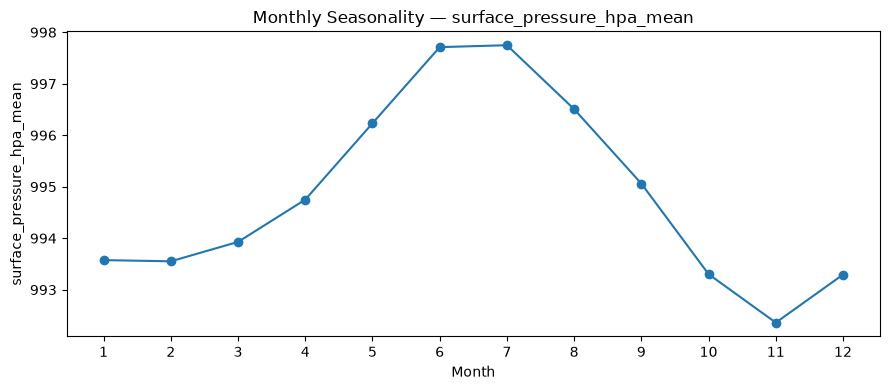

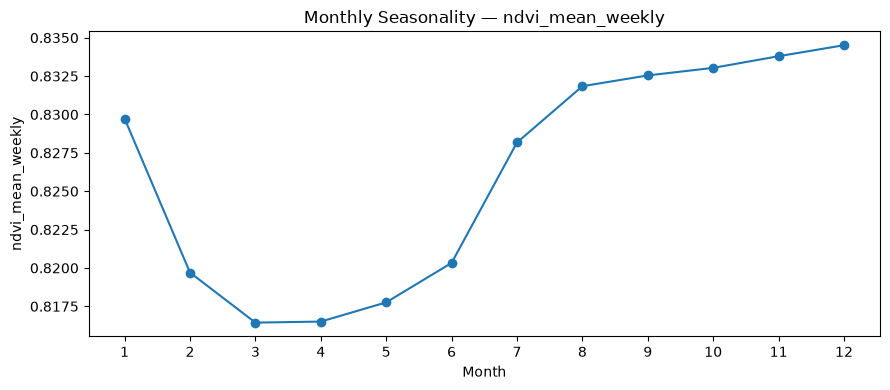

In [54]:
for column in seasonal_features:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(
        monthly_environment.index,
        monthly_environment[column],
        marker="o"
    )

    ax.set_title(f"Monthly Seasonality — {column}")
    ax.set_xlabel("Month")
    ax.set_ylabel(column)
    ax.set_xticks(range(1, 13))

    plt.tight_layout()
    plt.show()

### Interpretation — environmental behaviour

The environmental variables also show pronounced annual cycles. Rainfall, humidity, temperature and pressure vary systematically through the year. Consequently, some apparent environmental relationships with dengue may partly reflect **shared seasonality** rather than an independent predictive effect.

This is another reason to include explicit seasonal features and to judge environmental variables by out-of-sample forecasting performance rather than correlation alone.


## 5. Environment–dengue relationships

This section moves from description to exploratory association. It considers contemporaneous correlations, predictor redundancy, delayed relationships and rolling environmental conditions.


### 5.1 Predictor redundancy and correlation structure


In [55]:
analysis_features = [
    column
    for column in core_environmental_features
    if column in df.columns
]

corr_matrix = df[
    ["dengue_cases"] + analysis_features
].corr()

corr_matrix.round(3)

,dengue_cases,precip_sum_mm,precip_max_daily_mm,rain_days,temperature_c_mean,temperature_c_min,temperature_c_max,relative_humidity_pct_mean,dewpoint_c_mean,specific_humidity_kgkg_mean,wind_speed_ms_mean,wind_speed_ms_max,surface_pressure_hpa_mean,ndvi_mean_weekly,ndvi_median_weekly
dengue_cases,1.000,-0.001,-0.014,0.056,0.032,0.106,-0.047,0.071,0.110,0.113,0.052,0.094,-0.167,-0.085,-0.126
precip_sum_mm,-0.001,1.000,0.796,0.575,-0.059,0.244,-0.319,0.477,0.496,0.491,-0.201,-0.097,-0.201,-0.271,-0.093
precip_max_daily_mm,-0.014,0.796,1.000,0.293,-0.090,0.081,-0.213,0.331,0.305,0.301,-0.098,-0.038,-0.083,-0.213,-0.069
rain_days,0.056,0.575,0.293,1.000,0.113,0.407,-0.181,0.389,0.536,0.525,-0.248,-0.171,-0.294,-0.145,-0.063
temperature_c_mean,0.032,-0.059,-0.090,0.113,1.000,0.628,0.680,-0.524,0.209,0.241,0.350,0.310,-0.698,0.337,0.081
temperature_c_min,0.106,0.244,0.081,0.407,0.628,1.000,0.049,0.156,0.687,0.700,0.041,0.117,-0.720,0.024,0.000
temperature_c_max,-0.047,-0.319,-0.213,-0.181,0.680,0.049,1.000,-0.771,-0.336,-0.314,0.403,0.257,-0.194,0.403,0.098
relative_humidity_pct_mean,0.071,0.477,0.331,0.389,-0.524,0.156,-0.771,1.000,0.722,0.698,-0.467,-0.259,-0.026,-0.380,-0.083
dewpoint_c_mean,0.110,0.496,0.305,0.536,0.209,0.687,-0.336,0.722,1.000,0.998,-0.244,-0.040,-0.594,-0.154,-0.028
specific_humidity_kgkg_mean,0.113,0.491,0.301,0.525,0.241,0.700,-0.314,0.698,0.998,1.000,-0.226,-0.018,-0.625,-0.139,-0.021


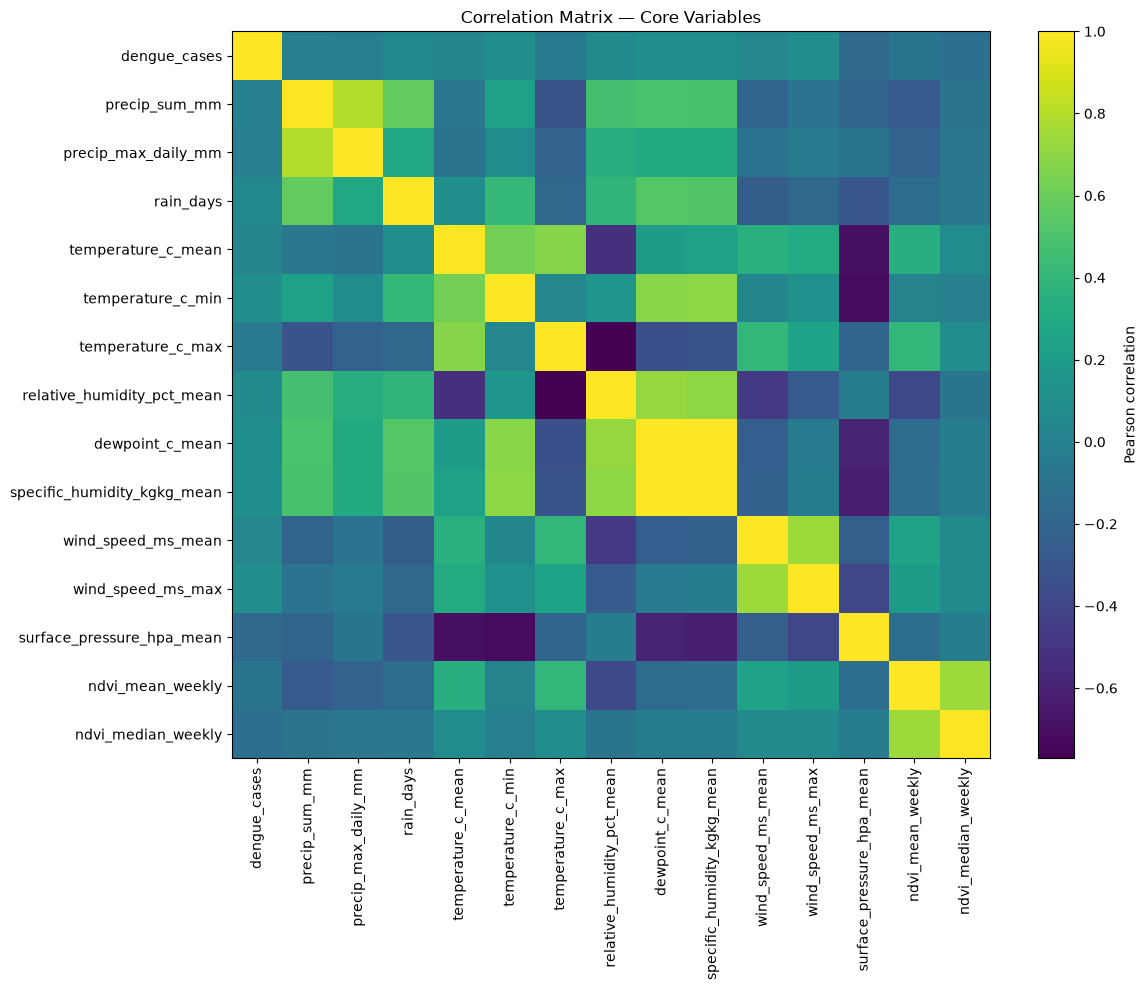

In [56]:
fig, ax = plt.subplots(
    figsize=(12, 10)
)

image = ax.imshow(
    corr_matrix,
    aspect="auto"
)

ax.set_xticks(
    range(len(corr_matrix.columns))
)

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90
)

ax.set_yticks(
    range(len(corr_matrix.index))
)

ax.set_yticklabels(
    corr_matrix.index
)

ax.set_title("Correlation Matrix — Core Variables")

fig.colorbar(
    image,
    ax=ax,
    label="Pearson correlation"
)

plt.tight_layout()
plt.show()

### Correlation with dengue cases

Pearson and Spearman correlations are both shown. Spearman correlation is particularly useful here because the dengue target is highly skewed and relationships may be monotonic without being linear.

In [57]:
correlation_with_target = []

for column in analysis_features:
    valid = df[
        ["dengue_cases", column]
    ].dropna()

    pearson = valid[
        "dengue_cases"
    ].corr(
        valid[column],
        method="pearson"
    )

    spearman = valid[
        "dengue_cases"
    ].corr(
        valid[column],
        method="spearman"
    )

    correlation_with_target.append({
        "feature": column,
        "pearson_r": pearson,
        "spearman_rho": spearman,
        "abs_spearman": abs(spearman),
    })

target_corr_df = (
    pd.DataFrame(
        correlation_with_target
    )
    .sort_values(
        "abs_spearman",
        ascending=False
    )
)

target_corr_df

,feature,pearson_r,spearman_rho,abs_spearman
8,specific_humidity_kgkg_mean,0.113317,0.339826,0.339826
7,dewpoint_c_mean,0.109775,0.338049,0.338049
6,relative_humidity_pct_mean,0.071442,0.283894,0.283894
11,surface_pressure_hpa_mean,-0.167391,-0.276939,0.276939
4,temperature_c_min,0.105848,0.241538,0.241538
5,temperature_c_max,-0.047396,-0.200119,0.200119
0,precip_sum_mm,-0.001407,0.141222,0.141222
10,wind_speed_ms_max,0.093799,0.115108,0.115108
12,ndvi_mean_weekly,-0.085293,-0.104342,0.104342
1,precip_max_daily_mm,-0.013944,0.096205,0.096205


### Interpretation — contemporaneous relationships

The strongest same-week associations are concentrated around **specific humidity, dew point, relative humidity and surface pressure**. Spearman correlations are noticeably stronger than Pearson correlations for several variables. This suggests that important relationships may be monotonic or non-linear rather than well represented by a simple straight line.

There is also substantial predictor redundancy. In particular, dew point and specific humidity are almost interchangeable statistically, while some precipitation summaries are near-deterministic transformations of one another. These variables should remain visible during EDA, but the final feature set should avoid unnecessary duplication.


### 5.2 Environmental lag analysis

For a lag of `n`, the environmental value comes from `n` weeks before the current dengue observation. Only historical information is used.


In [58]:
lag_features = [
    column
    for column in [
        "precip_sum_mm",
        "temperature_c_mean",
        "relative_humidity_pct_mean",
        "specific_humidity_kgkg_mean",
        "wind_speed_ms_mean",
        "surface_pressure_hpa_mean",
        "ndvi_mean_weekly",
    ]
    if column in df.columns
]

MAX_LAG_WEEKS = 12

lag_results = []

for feature in lag_features:

    for lag in range(
        0,
        MAX_LAG_WEEKS + 1
    ):

        lagged_feature = df[
            feature
        ].shift(lag)

        valid = pd.DataFrame({
            "dengue_cases":
                df["dengue_cases"],

            "lagged_feature":
                lagged_feature,
        }).dropna()

        pearson = valid[
            "dengue_cases"
        ].corr(
            valid[
                "lagged_feature"
            ],
            method="pearson"
        )

        spearman = valid[
            "dengue_cases"
        ].corr(
            valid[
                "lagged_feature"
            ],
            method="spearman"
        )

        lag_results.append({
            "feature":
                feature,

            "lag_weeks":
                lag,

            "pearson_r":
                pearson,

            "spearman_rho":
                spearman,
        })

lag_df = pd.DataFrame(
    lag_results
)

lag_df.head()

,feature,lag_weeks,pearson_r,spearman_rho
0,precip_sum_mm,0,-0.001407,0.141222
1,precip_sum_mm,1,-0.011605,0.136647
2,precip_sum_mm,2,-0.029160,0.126904
3,precip_sum_mm,3,-0.034284,0.126516
4,precip_sum_mm,4,-0.030501,0.130887


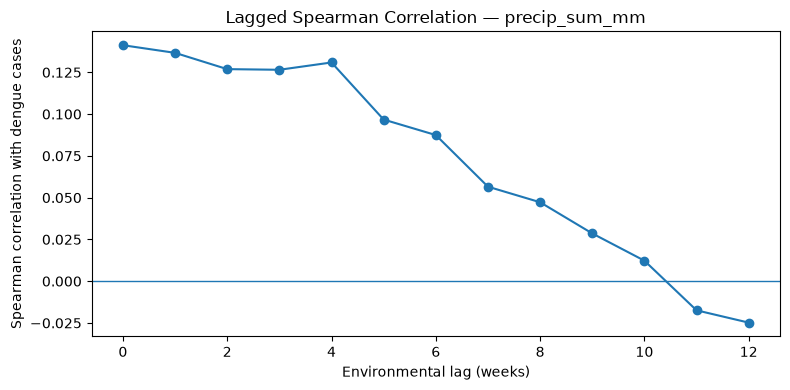

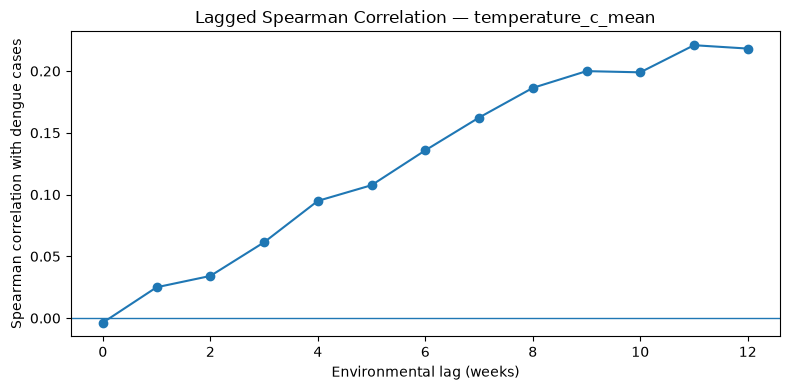

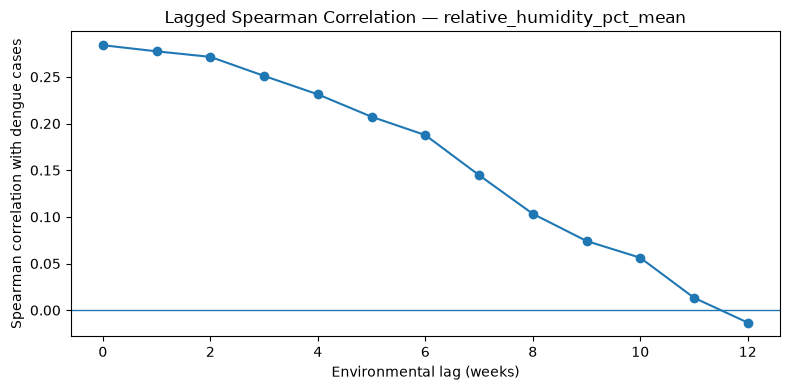

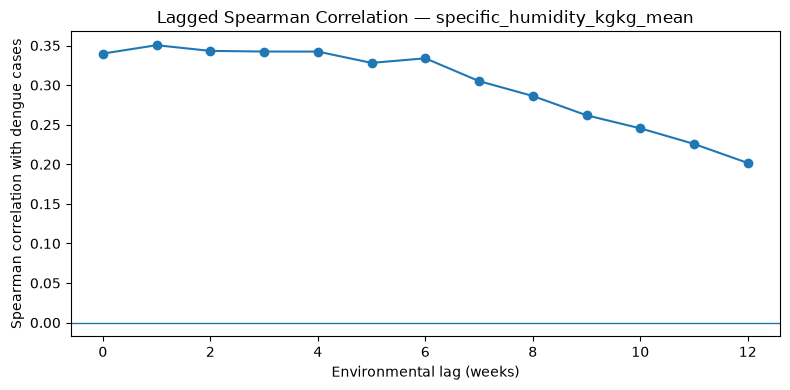

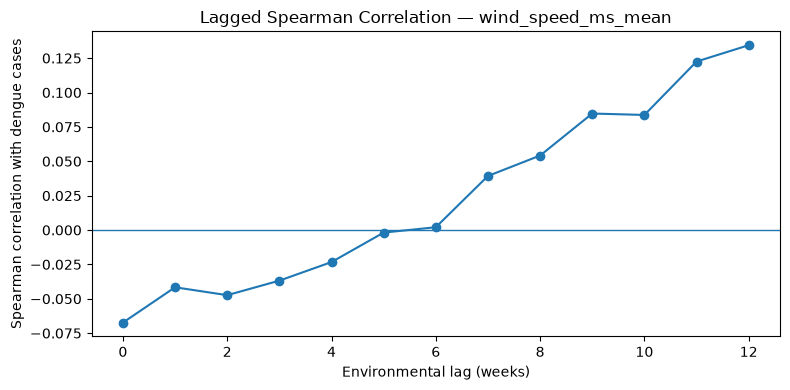

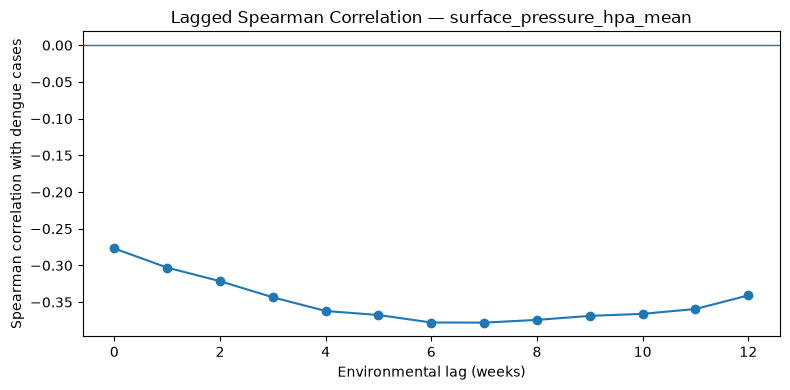

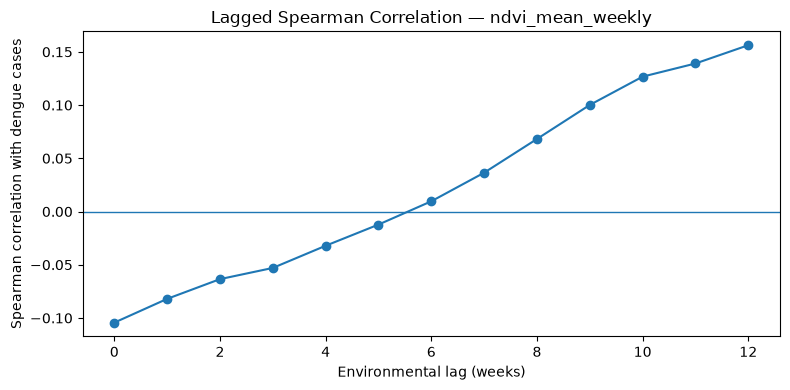

In [59]:
for feature in lag_features:

    subset = lag_df[
        lag_df[
            "feature"
        ] == feature
    ]

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    ax.plot(
        subset[
            "lag_weeks"
        ],
        subset[
            "spearman_rho"
        ],
        marker="o"
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_title(
        f"Lagged Spearman Correlation — {feature}"
    )

    ax.set_xlabel(
        "Environmental lag (weeks)"
    )

    ax.set_ylabel(
        "Spearman correlation with dengue cases"
    )

    plt.tight_layout()
    plt.show()

In [60]:
best_lags = (
    lag_df
    .assign(
        abs_spearman=lambda x:
            x[
                "spearman_rho"
            ].abs()
    )
    .sort_values(
        [
            "feature",
            "abs_spearman"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "feature",
        as_index=False
    )
    .first()
    .sort_values(
        "abs_spearman",
        ascending=False
    )
)

best_lags

,feature,lag_weeks,pearson_r,spearman_rho,abs_spearman
4,surface_pressure_hpa_mean,7,-0.227025,-0.377932,0.377932
3,specific_humidity_kgkg_mean,1,0.104283,0.350400,0.350400
2,relative_humidity_pct_mean,0,0.071442,0.283894,0.283894
5,temperature_c_mean,11,0.137240,0.220916,0.220916
0,ndvi_mean_weekly,12,0.036805,0.156260,0.156260
1,precip_sum_mm,0,-0.001407,0.141222,0.141222
6,wind_speed_ms_mean,12,0.201604,0.134403,0.134403


### Interpretation — environmental lags

The exploratory lag profiles provide evidence that delayed environmental effects are worth considering. The strongest observed Spearman relationships include:

- surface pressure at approximately **7 weeks**;
- specific humidity at approximately **1 week**;
- relative humidity contemporaneously;
- temperature at a longer lag of approximately **11 weeks**;
- NDVI and wind at longer exploratory lags.

These maxima should **not** be interpreted as proof that each environmental variable causes dengue after exactly that delay. Seasonal structure and autocorrelation can also create peaks in lagged correlations. They should instead guide a small, biologically plausible set of candidate lags for feature engineering.


### 5.3 Rolling environmental conditions


In [61]:
rolling_candidates = {}

if "precip_sum_mm" in df.columns:
    rolling_candidates[
        "precip_4week_sum"
    ] = (
        df[
            "precip_sum_mm"
        ]
        .rolling(
            4,
            min_periods=4
        )
        .sum()
    )

if "temperature_c_mean" in df.columns:
    rolling_candidates[
        "temperature_4week_mean"
    ] = (
        df[
            "temperature_c_mean"
        ]
        .rolling(
            4,
            min_periods=4
        )
        .mean()
    )

if "relative_humidity_pct_mean" in df.columns:
    rolling_candidates[
        "humidity_4week_mean"
    ] = (
        df[
            "relative_humidity_pct_mean"
        ]
        .rolling(
            4,
            min_periods=4
        )
        .mean()
    )

if "ndvi_mean_weekly" in df.columns:
    rolling_candidates[
        "ndvi_4week_mean"
    ] = (
        df[
            "ndvi_mean_weekly"
        ]
        .rolling(
            4,
            min_periods=4
        )
        .mean()
    )

rolling_corr_rows = []

for name, series in rolling_candidates.items():

    valid = pd.DataFrame({
        "dengue_cases":
            df[
                "dengue_cases"
            ],

        "feature":
            series,
    }).dropna()

    rolling_corr_rows.append({
        "feature":
            name,

        "pearson_r":
            valid[
                "dengue_cases"
            ].corr(
                valid[
                    "feature"
                ],
                method="pearson"
            ),

        "spearman_rho":
            valid[
                "dengue_cases"
            ].corr(
                valid[
                    "feature"
                ],
                method="spearman"
            ),
    })

pd.DataFrame(
    rolling_corr_rows
)

,feature,pearson_r,spearman_rho
0,precip_4week_sum,-0.031385,0.213286
1,temperature_4week_mean,0.050994,0.024881
2,humidity_4week_mean,0.059835,0.315646
3,ndvi_4week_mean,-0.042457,-0.094204


### Interpretation — rolling conditions

Recent accumulated conditions can be more informative than an isolated week. In this exploratory comparison, the four-week precipitation sum has a stronger Spearman relationship with dengue than same-week precipitation, and the four-week mean of relative humidity also strengthens the association.

This supports testing selected rolling summaries during feature engineering rather than creating a large number of arbitrary windows.


## 6. Consolidated EDA findings

The EDA supports the following conclusions:

- **Dengue is highly persistent over time.** Recent case counts contain substantially more direct predictive information than any individual environmental variable examined here.
- **The target is strongly right-skewed**, with genuine epidemic peaks that should remain in the modelling problem.
- **Seasonality is important** in both dengue and the environmental predictors.
- **Humidity-related variables show the strongest contemporaneous environmental relationships**, although their effects appear more monotonic/non-linear than purely linear.
- **Delayed environmental effects are plausible**, supporting targeted lag engineering.
- **Rolling rainfall and humidity summaries are promising** candidate features.
- **Predictor redundancy is substantial**, particularly among dew point/specific humidity and alternative precipitation summaries.
- **Data-quality issues are limited and documented**; none require restarting the data-engineering pipeline.

These findings should inform feature engineering, but correlation magnitude alone should not determine which variables enter the final models.


## 7. EDA outputs

Save compact analytical tables for the next feature-engineering stage. These outputs contain no absolute workplace file paths.


In [62]:
target_corr_df.to_csv(
    OUTPUT_DIR / "eda_target_correlations.csv",
    index=False
)

lag_df.to_csv(
    OUTPUT_DIR / "eda_environmental_lag_correlations.csv",
    index=False
)

best_lags.to_csv(
    OUTPUT_DIR / "eda_best_environmental_lags.csv",
    index=False
)

dengue_lag_df.to_csv(
    OUTPUT_DIR / "eda_dengue_lag_correlations.csv",
    index=False
)

annual_cases.to_csv(
    OUTPUT_DIR / "eda_annual_dengue_summary.csv",
    index=False
)

monthly_dengue.to_csv(
    OUTPUT_DIR / "eda_monthly_dengue_summary.csv",
    index=False
)

print("EDA tables saved to outputs/eda/")


EDA tables saved to outputs/eda/


## 8. Feature-engineering decisions

1. retain `dengue_cases` as the untransformed target initially;
2. engineer cyclical seasonality features;
3. create a small set of historical dengue lags informed by the strong autocorrelation profile;
4. create selected environmental lags supported by EDA and epidemiological plausibility;
5. test a limited number of rolling summaries for rainfall, humidity, temperature and NDVI;
6. reduce clearly redundant predictor representations;
7. retain relevant QA indicators;
8. handle the six pre-MODIS NDVI rows without using future information;
9. use chronological train/validation/test splits;
10. compare a dengue-history baseline against climate-enhanced models.

The central modelling question is therefore not simply whether climate correlates with dengue, but whether environmental information **improves future prediction beyond seasonality and recent dengue incidence**.
